In [ ]:
from google.colab import drive
drive.mount('/content/drive')
path = '/content/drive/MyDrive/Colab Notebooks/ImageProcessing/Lab6/'

Mounted at /content/drive


In [ ]:
import cv2
import numpy as np
from matplotlib import pyplot as plt

In [ ]:
#Erosion Operation
def erosion(image,se):
  h, w = image.shape
  mask = se.astype(bool)

  temp1 = np.zeros((image.shape[0]+2, image.shape[1]+2), np.uint8)
  temp1[1:h+1, 1:w+1] = image

  erosion = np.zeros_like(image)
  for i in range(1, h+1):
    for j in range(1, w+1):
        region = temp1[i-1:i+2, j-1:j+2]

        if np.all(region[mask] == 255):
            erosion[i-1, j-1] = 255
        else:
            erosion[i-1, j-1] = 0

  return erosion

#Dilation Operation
def dilation(image,se):
  h, w = image.shape
  mask = se.astype(bool)

  temp2 = np.zeros((image.shape[0]+2, image.shape[1]+2), np.uint8)
  temp2[1:h+1, 1:w+1] = image

  dilation = np.zeros_like(image)
  for i in range(1, h+1):
    for j in range(1, w+1):
      region = temp2[i-1:i+2, j-1:j+2]

      if np.any(region[mask] == 255):
          dilation[i-1, j-1] = 255
      else:
          dilation[i-1, j-1] = 0

  return dilation


1) Morphological image processing using erosion

Text(0.5, 1.0, 'Output Image')

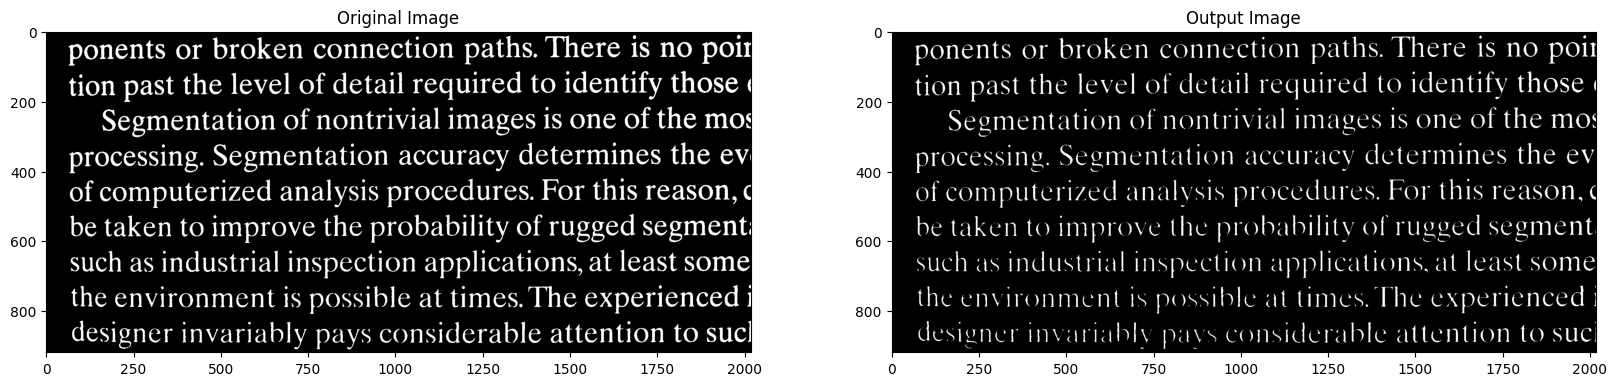

In [ ]:
image1_path = path + "text_image.tif"
image1 = cv2.imread(image1_path, 0)

se1 = np.array([
  [1, 1, 1],
  [1, 1, 1],
  [1, 1, 1]
], np.uint8)

erosion_image = erosion(image1,se1)

plt.figure(figsize=(20,20))
plt.subplot(1,2,1)
plt.imshow(image1, cmap='gray')
plt.title('Original Image')

plt.subplot(1,2,2)
plt.imshow(erosion_image, cmap='gray')
plt.title('Output Image')

2) Morphological image processing using dilation

Text(0.5, 1.0, 'Output Image')

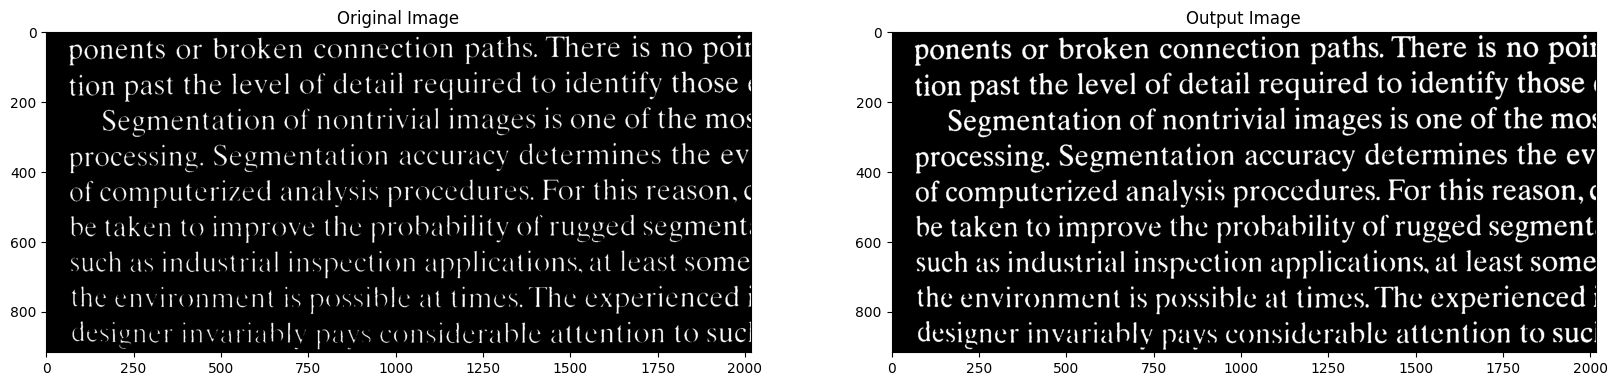

In [ ]:
image2_path = path + "text-gaps_1_pixel.tif"
image2 = cv2.imread(image2_path, 0)

se2 = np.array([
  [1, 1, 1],
  [1, 1, 1],
  [1, 1, 1]
], np.uint8)

dilation_image = dilation(image2,se2)

plt.figure(figsize=(20,20))
plt.subplot(1,2,1)
plt.imshow(image2, cmap='gray')
plt.title('Original Image')

plt.subplot(1,2,2)
plt.imshow(dilation_image, cmap='gray')
plt.title('Output Image')

3) Morphological image processing using the opening

Text(0.5, 1.0, 'Output Image')

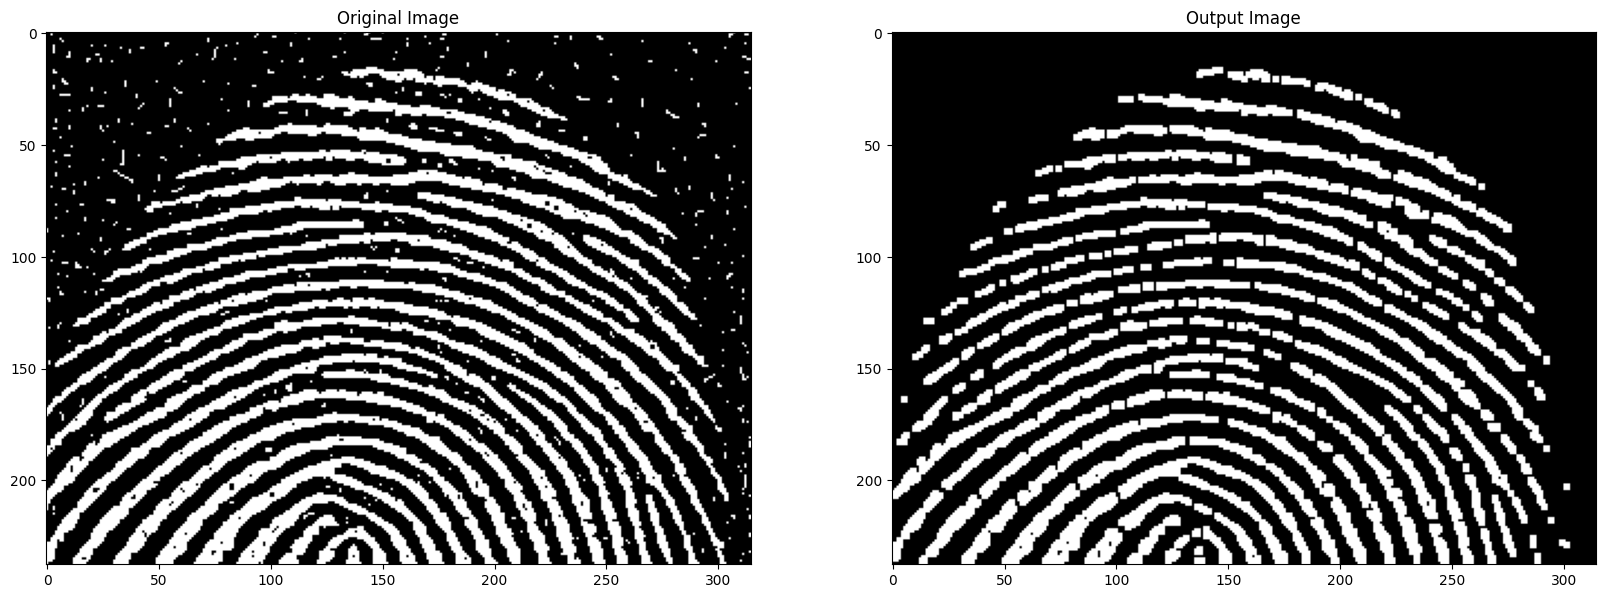

In [ ]:
image3_path = path + "noisy_fingerprint.tif"
image3 = cv2.imread(image3_path, 0)

se3 = np.array([
  [1, 1, 1],
  [1, 1, 1],
  [1, 1, 1]
], np.uint8)

opening_image = dilation(erosion(image3,se3),se3)

plt.figure(figsize=(20,20))
plt.subplot(1,2,1)
plt.imshow(image3, cmap='gray')
plt.title('Original Image')

plt.subplot(1,2,2)
plt.imshow(opening_image, cmap='gray')
plt.title('Output Image')

4) Morphological image processing using the closing

Text(0.5, 1.0, 'Output Image')

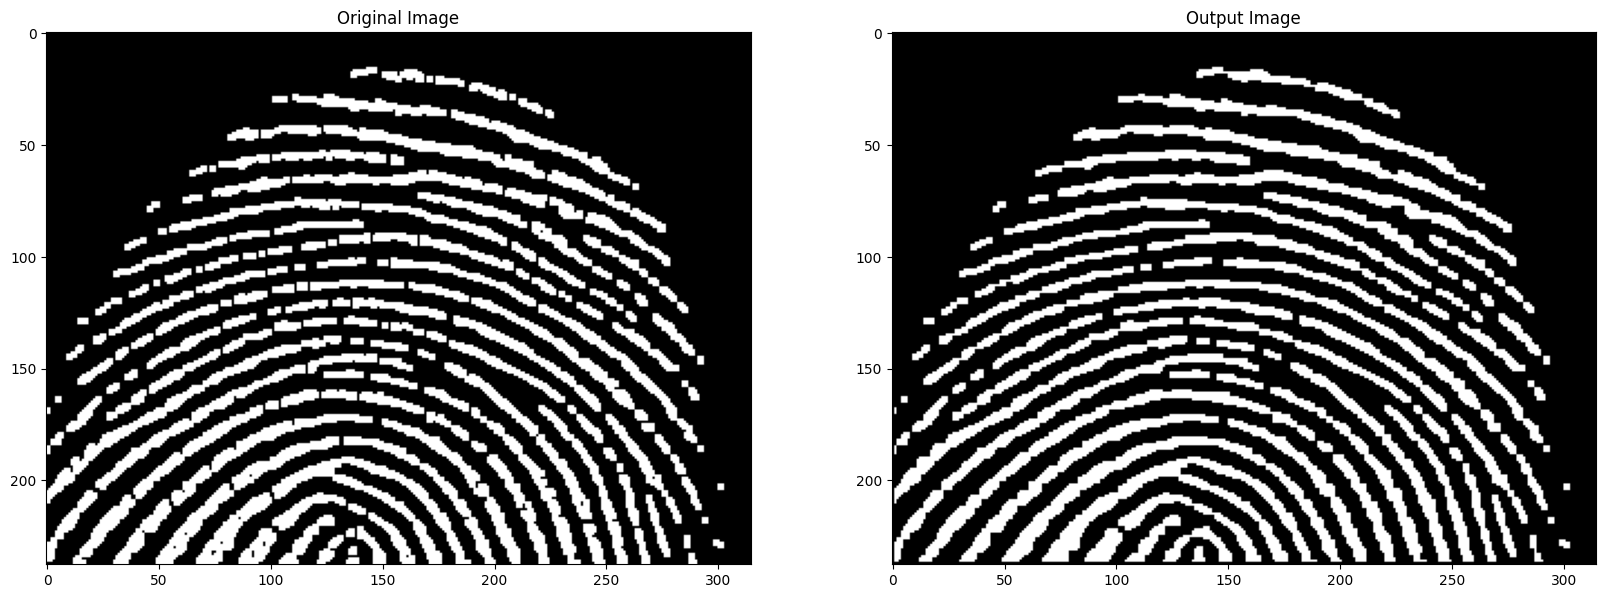

In [ ]:
image4_path = path + "opening_fingerprint.tif"
image4 = cv2.imread(image4_path, 0)

se4 = np.array([
  [1, 1, 1],
  [1, 1, 1],
  [1, 1, 1]
], np.uint8)

closing_image = erosion(dilation(image4,se4),se4)

plt.figure(figsize=(20,20))
plt.subplot(1,2,1)
plt.imshow(image4, cmap='gray')
plt.title('Original Image')

plt.subplot(1,2,2)
plt.imshow(closing_image, cmap='gray')
plt.title('Output Image')